In [66]:
pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [67]:
import pandas as pd
import matplotlib.pyplot as plt

In [68]:
dataset = pd.read_csv('dataset.csv')

In [69]:
print(dataset.columns)


Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [70]:
dataset.columns = dataset.columns.str.strip()


In [71]:
print(dataset.head())


   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0             54865              3                  2                       0   
1             55054            109                  1                       1   
2             55055             52                  1                       1   
3             46236             34                  1                       1   
4             54863              3                  2                       0   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                           12                            0   
1                            6                            6   
2                            6                            6   
3                            6                            6   
4                           12                            0   

   Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  \
0                      6                      6            

In [72]:
import pandas as pd


df = pd.DataFrame()

# Remove rows where all values are zero
df = df[(df != 0).any(axis=1)]

print(df)


Empty DataFrame
Columns: []
Index: []


In [73]:
dataset.columns = dataset.columns.str.strip()


In [74]:
dataset = dataset.dropna()


In [75]:
dataset = dataset[(dataset != 0).any(axis=1)]


Dataset loaded successfully!
Dataset Columns: Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Pa

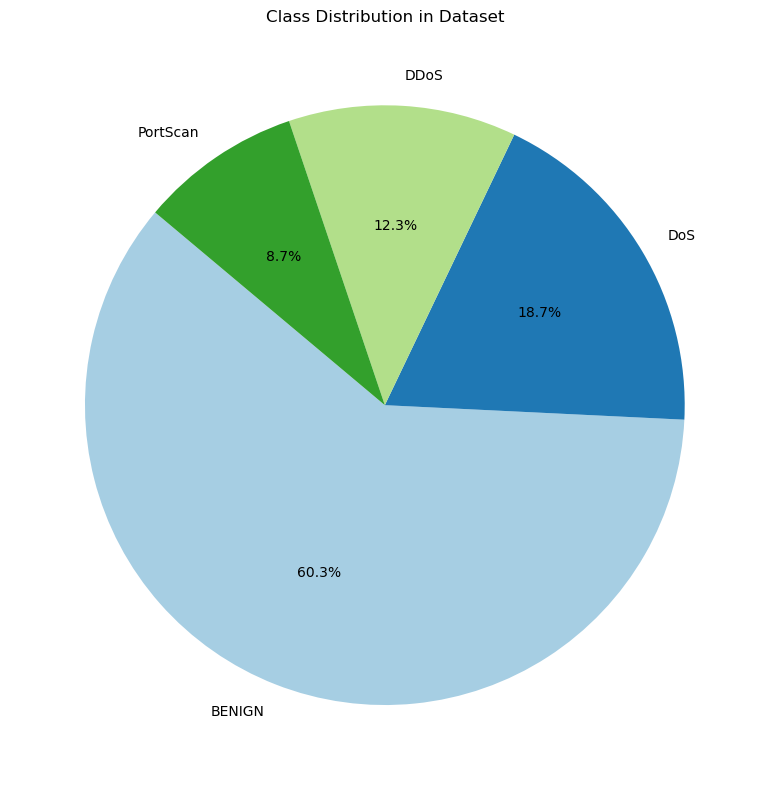

Class distribution pie chart saved as C:\Users\aadil\Downloads\class_distribution.png
Epoch 1/30
13032/13032 [==============================] - 42s 3ms/step - loss: 0.2114 - accuracy: 0.9317 - val_loss: 0.0523 - val_accuracy: 0.9815
Epoch 2/30
13032/13032 [==============================] - 42s 3ms/step - loss: 0.0686 - accuracy: 0.9779 - val_loss: 0.0336 - val_accuracy: 0.9851
Epoch 3/30
13032/13032 [==============================] - 42s 3ms/step - loss: 0.0467 - accuracy: 0.9840 - val_loss: 0.0281 - val_accuracy: 0.9875
Epoch 4/30
13032/13032 [==============================] - 44s 3ms/step - loss: 0.0365 - accuracy: 0.9871 - val_loss: 0.0212 - val_accuracy: 0.9936
Epoch 5/30
13032/13032 [==============================] - 42s 3ms/step - loss: 0.0312 - accuracy: 0.9892 - val_loss: 0.0180 - val_accuracy: 0.9932
Epoch 6/30
13032/13032 [==============================] - 42s 3ms/step - loss: 0.0275 - accuracy: 0.9911 - val_loss: 0.0149 - val_accuracy: 0.9946
Epoch 7/30
13032/13032 [========

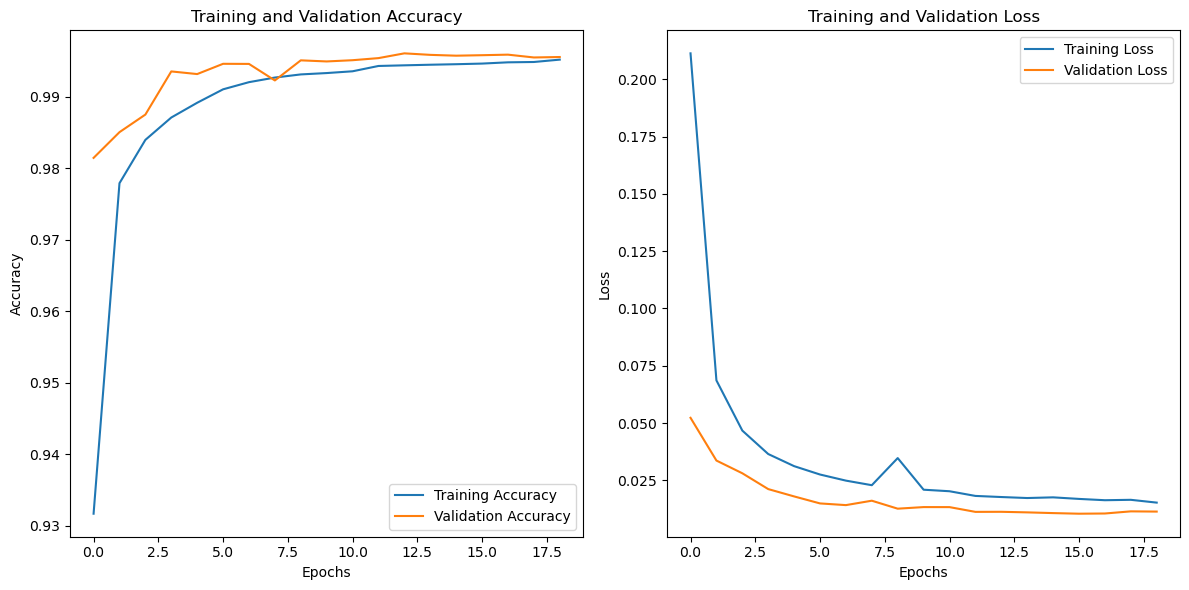

Enhanced performance visualization saved as C:\Users\aadil\Downloads\model_performance.png


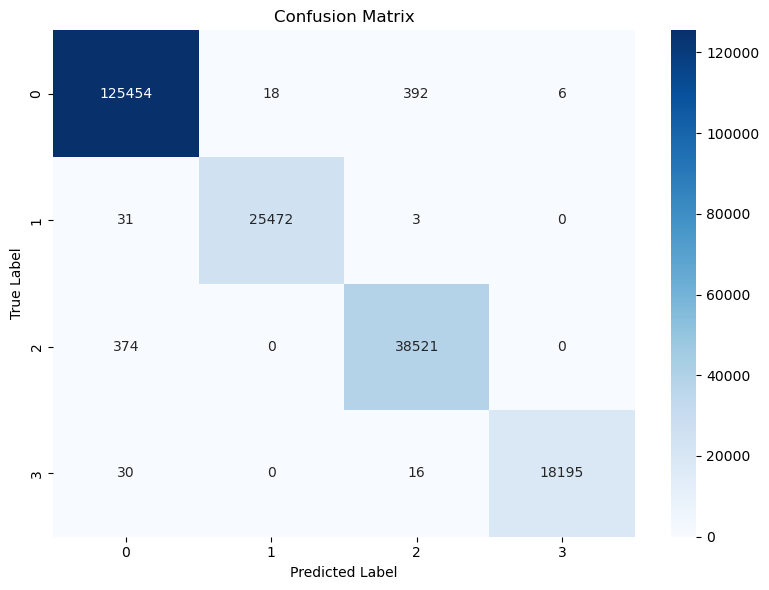

Confusion matrix saved as C:\Users\aadil\Downloads\confusion_matrix.png


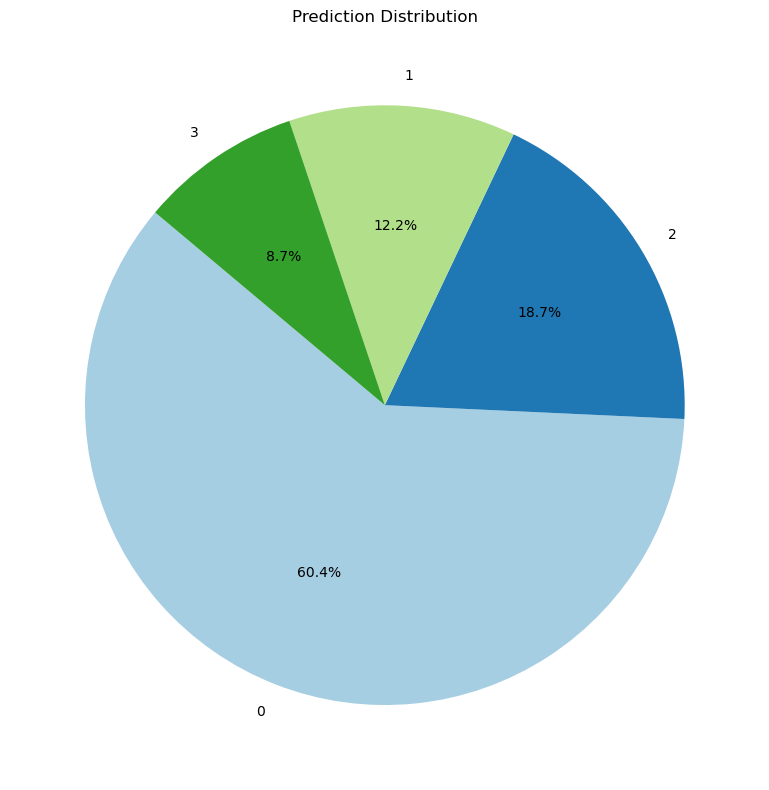

Prediction distribution pie chart saved as C:\Users\aadil\Downloads\prediction_distribution.png

Model Results Summary:
                Metric     Value
0  Validation Accuracy  0.995828
1      Validation Loss  0.010406
2             F1 Score  0.995828
3            Precision  0.995830
4               Recall  0.995828
Results summary saved to C:\Users\aadil\Downloads\results_summary.csv


In [76]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
import seaborn as sns

# Load the dataset
dataset_path = r'dataset.csv'  # Adjust the path to your dataset
try:
    dataset = pd.read_csv(dataset_path)
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print(f"Error: File not found at {dataset_path}")
    exit()

# Debugging step: Print column names to verify structure
print("Dataset Columns:", dataset.columns)

# Assuming the last column is the label and the rest are features
X = dataset.iloc[:, :-1].values  # All columns except the last one are features
y_raw = dataset.iloc[:, -1]  # Last column is the raw label (non-encoded)
y = pd.get_dummies(y_raw)  # One-hot encoding of the labels
num_classes = y.shape[1]

# Pie chart for class distribution
class_counts = y_raw.value_counts()
plt.figure(figsize=(8, 8))
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title("Class Distribution in Dataset")
class_distribution_path = r'C:\Users\aadil\Downloads\class_distribution.png'
plt.tight_layout()
plt.savefig(class_distribution_path, dpi=300)
plt.show()
print(f"Class distribution pie chart saved as {class_distribution_path}")

# Check for NaN, Infinite or Large values in X
if np.any(np.isnan(X)) or np.any(np.isinf(X)):
    print("Warning: Dataset contains NaN or Infinite values.")
    X = np.nan_to_num(X, nan=np.nanmean(X, axis=0), posinf=np.nanmax(X, axis=0), neginf=np.nanmin(X, axis=0))

# Cap extremely large values (optional)
max_value = 1e10
X[np.abs(X) > max_value] = max_value

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Model parameters
input_dim = X_train.shape[1]  # Number of features

# Build the neural network model
model = Sequential([
    Dense(128, input_dim=input_dim, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Define callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
    ModelCheckpoint(filepath='best_model.h5', monitor='val_accuracy', save_best_only=True)
]

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=callbacks
)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_val, y_val)
print(f"Validation Accuracy: {test_accuracy}")

# Calculate additional metrics
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val.values, axis=1)

f1 = f1_score(y_true_classes, y_pred_classes, average='weighted')
precision = precision_score(y_true_classes, y_pred_classes, average='weighted')
recall = recall_score(y_true_classes, y_pred_classes, average='weighted')

# Plot training and validation accuracy & loss
plt.figure(figsize=(12, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Save the plots
output_path = r'C:\Users\aadil\Downloads\model_performance.png'
plt.tight_layout()
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Enhanced performance visualization saved as {output_path}")

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=np.arange(num_classes), yticklabels=np.arange(num_classes))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Save the confusion matrix plot
conf_matrix_path = r'C:\Users\aadil\Downloads\confusion_matrix.png'
plt.tight_layout()
plt.savefig(conf_matrix_path, dpi=300)
plt.show()
print(f"Confusion matrix saved as {conf_matrix_path}")

# Create pie chart for predictions
predicted_class_counts = pd.Series(y_pred_classes).value_counts()
plt.figure(figsize=(8, 8))
plt.pie(predicted_class_counts, labels=predicted_class_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title("Prediction Distribution")
prediction_distribution_path = r'C:\Users\aadil\Downloads\prediction_distribution.png'
plt.tight_layout()
plt.savefig(prediction_distribution_path, dpi=300)
plt.show()
print(f"Prediction distribution pie chart saved as {prediction_distribution_path}")

# Create a results summary table
results_summary = pd.DataFrame({
    'Metric': ['Validation Accuracy', 'Validation Loss', 'F1 Score', 'Precision', 'Recall'],
    'Value': [test_accuracy, test_loss, f1, precision, recall]
})
print("\nModel Results Summary:")
print(results_summary)

# Save results to a CSV file
results_csv_path = r'C:\Users\aadil\Downloads\results_summary.csv'
results_summary.to_csv(results_csv_path, index=False)
print(f"Results summary saved to {results_csv_path}")
